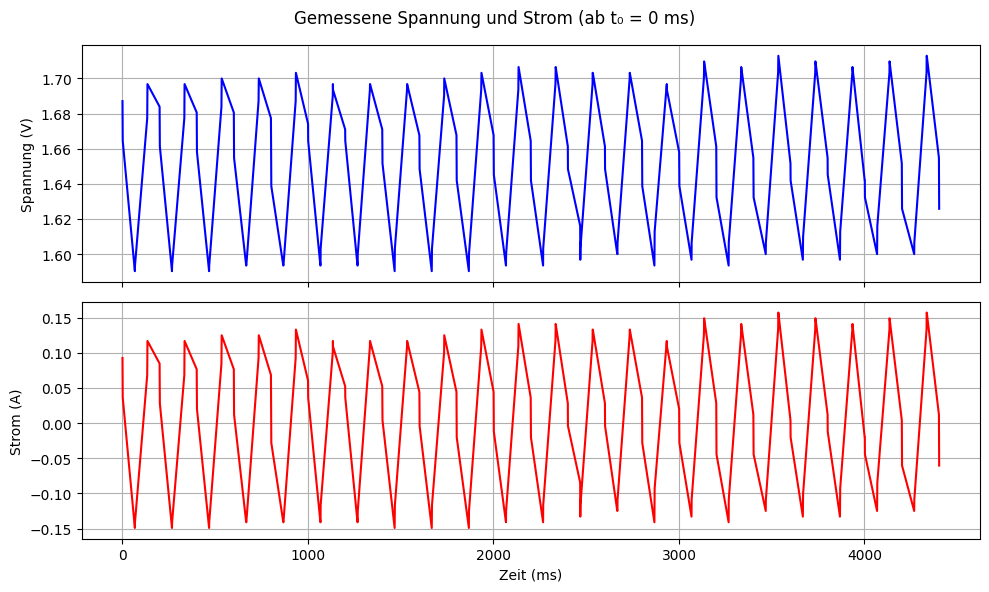

----- Abtastraten-Analyse -----
Anzahl Messpunkte:       176
Anzahl Zeitabstände:     175
Ziel-Abtastrate:         3000.00 Hz
Soll-Periode:            333.33 µs
Mittlere Periode:        25159.09 µs
Reale Abtastrate:        39.75 Hz
Abweichung:              -98.68 %

----- Strom-RMS -----
Anzahl Messpunkte (I):   176
DC + AC RMS:             0.103419 A
AC-RMS (ohne DC-Anteil): 0.103168 A
DC-Offset (Mittelwert):  0.007195 A

----- Aufgenommene Leistung (vereinfacht) -----
Angenommene Spannung:    220.0 V
P ≈ I_rms * 220 V:       22.752 W


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Daten einlesen ===
# Datei enthält: time_us, voltage_V, current_A (Whitespace-getrennt)
df = pd.read_csv(
    "dataVint_stuf1.txt",
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Mikrosekunden → Sekunden
df["time_s"] = df["time_us"] * 1e-6

# Zeit bei 0 starten lassen und in Millisekunden umrechnen
t0 = df["time_s"].iloc[0]
df["time_ms"] = (df["time_s"] - t0) * 1000.0   # Zeit in Millisekunden

# === 2️⃣ Getrennte Plots: Spannung (blau) & Strom (rot) ===
fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Spannung – blau
axV.plot(df["time_ms"], df["voltage_V"], color='b')
axV.set_ylabel("Spannung (V)")
axV.grid(True)

# Strom – rot
axI.plot(df["time_ms"], df["current_A"], color='r')
axI.set_ylabel("Strom (A)")
axI.set_xlabel("Zeit (ms)")
axI.grid(True)

plt.suptitle("Gemessene Spannung und Strom (ab t₀ = 0 ms)")
plt.tight_layout()
plt.show()

# === 3️⃣ Abtastraten-Analyse aus den Zeitstempeln ===

fs_target = 3000.0              # Ziel-Abtastrate in Hz (3 kHz)
T_target_us = 1e6 / fs_target   # Soll-Periode in µs

dt_us = df["time_us"].diff().dropna()  # Differenzen in µs

mean_dt_us = dt_us.mean()
fs_real = 1.0 / (mean_dt_us * 1e-6)

n_samples = len(df)
n_intervals = len(dt_us)

print("----- Abtastraten-Analyse -----")
print(f"Anzahl Messpunkte:       {n_samples}")
print(f"Anzahl Zeitabstände:     {n_intervals}")
print(f"Ziel-Abtastrate:         {fs_target:.2f} Hz")
print(f"Soll-Periode:            {T_target_us:.2f} µs")
print(f"Mittlere Periode:        {mean_dt_us:.2f} µs")
print(f"Reale Abtastrate:        {fs_real:.2f} Hz")
print(f"Abweichung:              {(fs_real - fs_target) / fs_target * 100:.2f} %")

# === 4️⃣ RMS (Effektivwert) des Stroms & Leistung ===

I = df["current_A"].to_numpy()
I_rms = np.sqrt(np.mean(I**2))

I_mean = np.mean(I)
I_rms_ac = np.sqrt(np.mean((I - I_mean)**2))

U_nom = 220.0  # angenommene Netzspannung in Volt
P_rms = I_rms * U_nom  # einfache Leistung: P = I_rms * 220 V

print("\n----- Strom-RMS -----")
print(f"Anzahl Messpunkte (I):   {len(I)}")
print(f"DC + AC RMS:             {I_rms:.6f} A")
print(f"AC-RMS (ohne DC-Anteil): {I_rms_ac:.6f} A")
print(f"DC-Offset (Mittelwert):  {I_mean:.6f} A")

print("\n----- Aufgenommene Leistung  -----")
print(f"Angenommene Spannung:    {U_nom:.1f} V")
print(f"P ≈ I_rms * 220 V:       {P_rms:.3f} W")


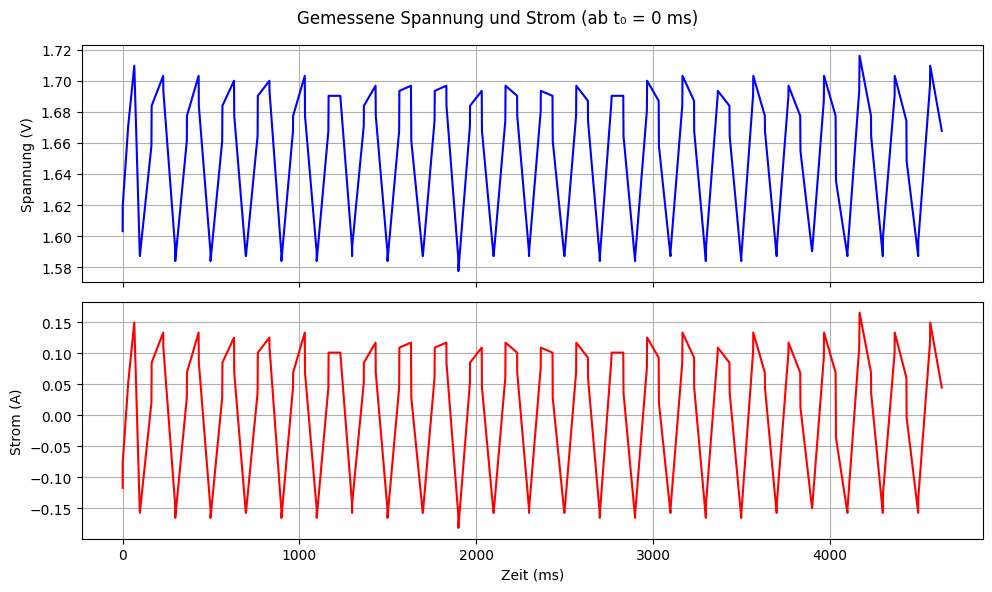

----- Abtastraten-Analyse -----
Anzahl Messpunkte:       176
Anzahl Zeitabstände:     175
Ziel-Abtastrate:         3000.00 Hz
Soll-Periode:            333.33 µs
Mittlere Periode:        26463.81 µs
Reale Abtastrate:        37.79 Hz
Abweichung:              -98.74 %

----- Strom-RMS -----
Anzahl Messpunkte (I):   176
DC + AC RMS:             0.114138 A
AC-RMS (ohne DC-Anteil): 0.113863 A
DC-Offset (Mittelwert):  0.007922 A

----- Aufgenommene Leistung (vereinfacht) -----
Angenommene Spannung:    220.0 V
P ≈ I_rms * 220 V:       25.110 W


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Daten einlesen ===
# Datei enthält: time_us, voltage_V, current_A (Whitespace-getrennt)
df = pd.read_csv(
    "dataVint_stuf2.txt",
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Mikrosekunden → Sekunden
df["time_s"] = df["time_us"] * 1e-6

# Zeit bei 0 starten lassen und in Millisekunden umrechnen
t0 = df["time_s"].iloc[0]
df["time_ms"] = (df["time_s"] - t0) * 1000.0   # Zeit in Millisekunden

# === 2️⃣ Getrennte Plots: Spannung (blau) & Strom (rot) ===
fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Spannung – blau
axV.plot(df["time_ms"], df["voltage_V"], color='b')
axV.set_ylabel("Spannung (V)")
axV.grid(True)

# Strom – rot
axI.plot(df["time_ms"], df["current_A"], color='r')
axI.set_ylabel("Strom (A)")
axI.set_xlabel("Zeit (ms)")
axI.grid(True)

plt.suptitle("Gemessene Spannung und Strom (ab t₀ = 0 ms)")
plt.tight_layout()
plt.show()

# === 3️⃣ Abtastraten-Analyse aus den Zeitstempeln ===

fs_target = 3000.0              # Ziel-Abtastrate in Hz (3 kHz)
T_target_us = 1e6 / fs_target   # Soll-Periode in µs

dt_us = df["time_us"].diff().dropna()  # Differenzen in µs

mean_dt_us = dt_us.mean()
fs_real = 1.0 / (mean_dt_us * 1e-6)

n_samples = len(df)
n_intervals = len(dt_us)

print("----- Abtastraten-Analyse -----")
print(f"Anzahl Messpunkte:       {n_samples}")
print(f"Anzahl Zeitabstände:     {n_intervals}")
print(f"Ziel-Abtastrate:         {fs_target:.2f} Hz")
print(f"Soll-Periode:            {T_target_us:.2f} µs")
print(f"Mittlere Periode:        {mean_dt_us:.2f} µs")
print(f"Reale Abtastrate:        {fs_real:.2f} Hz")
print(f"Abweichung:              {(fs_real - fs_target) / fs_target * 100:.2f} %")

# === 4️⃣ RMS (Effektivwert) des Stroms & Leistung ===

I = df["current_A"].to_numpy()
I_rms = np.sqrt(np.mean(I**2))

I_mean = np.mean(I)
I_rms_ac = np.sqrt(np.mean((I - I_mean)**2))

U_nom = 220.0  # angenommene Netzspannung in Volt
P_rms = I_rms * U_nom  # einfache Leistung: P = I_rms * 220 V

print("\n----- Strom-RMS -----")
print(f"Anzahl Messpunkte (I):   {len(I)}")
print(f"DC + AC RMS:             {I_rms:.6f} A")
print(f"AC-RMS (ohne DC-Anteil): {I_rms_ac:.6f} A")
print(f"DC-Offset (Mittelwert):  {I_mean:.6f} A")

print("\n----- Aufgenommene Leistung  -----")
print(f"Angenommene Spannung:    {U_nom:.1f} V")
print(f"P ≈ I_rms * 220 V:       {P_rms:.3f} W")


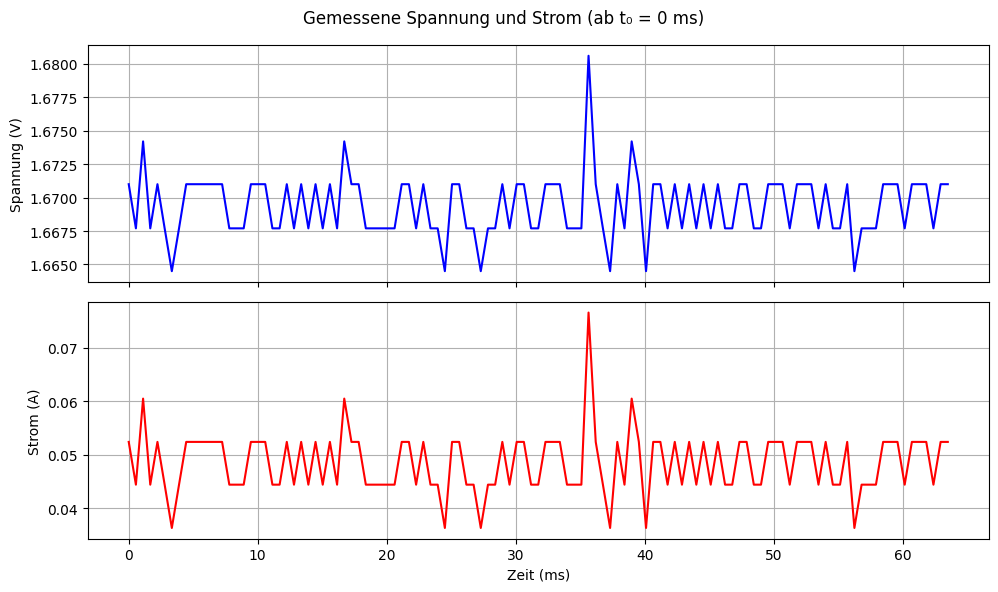

----- Abtastraten-Analyse -----
Anzahl Messpunkte:       115
Anzahl Zeitabstände:     114
Ziel-Abtastrate:         3000.00 Hz
Soll-Periode:            333.33 µs
Mittlere Periode:        557.10 µs
Reale Abtastrate:        1795.02 Hz
Abweichung:              -40.17 %

----- Strom-RMS -----
Anzahl Messpunkte (I):   115
DC + AC RMS:             0.048842 A
AC-RMS (ohne DC-Anteil): 0.005742 A
DC-Offset (Mittelwert):  0.048503 A

----- Aufgenommene Leistung  -----
Angenommene Spannung:    220.0 V
P ≈ I_rms * 220 V:       10.745 W


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Daten einlesen ===
# Datei enthält: time_us, voltage_V, current_A (Whitespace-getrennt)
df = pd.read_csv(
    "1_65data.txt",
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Mikrosekunden → Sekunden
df["time_s"] = df["time_us"] * 1e-6

# Zeit bei 0 starten lassen und in Millisekunden umrechnen
t0 = df["time_s"].iloc[0]
df["time_ms"] = (df["time_s"] - t0) * 1000.0   # Zeit in Millisekunden

# === 2️⃣ Getrennte Plots: Spannung (blau) & Strom (rot) ===
fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Spannung – blau
axV.plot(df["time_ms"], df["voltage_V"], color='b')
axV.set_ylabel("Spannung (V)")
axV.grid(True)

# Strom – rot
axI.plot(df["time_ms"], df["current_A"], color='r')
axI.set_ylabel("Strom (A)")
axI.set_xlabel("Zeit (ms)")
axI.grid(True)

plt.suptitle("Gemessene Spannung und Strom (ab t₀ = 0 ms)")
plt.tight_layout()
plt.show()

# === 3️⃣ Abtastraten-Analyse aus den Zeitstempeln ===

fs_target = 3000.0              # Ziel-Abtastrate in Hz (3 kHz)
T_target_us = 1e6 / fs_target   # Soll-Periode in µs

dt_us = df["time_us"].diff().dropna()  # Differenzen in µs

mean_dt_us = dt_us.mean()
fs_real = 1.0 / (mean_dt_us * 1e-6)

n_samples = len(df)
n_intervals = len(dt_us)

print("----- Abtastraten-Analyse -----")
print(f"Anzahl Messpunkte:       {n_samples}")
print(f"Anzahl Zeitabstände:     {n_intervals}")
print(f"Ziel-Abtastrate:         {fs_target:.2f} Hz")
print(f"Soll-Periode:            {T_target_us:.2f} µs")
print(f"Mittlere Periode:        {mean_dt_us:.2f} µs")
print(f"Reale Abtastrate:        {fs_real:.2f} Hz")
print(f"Abweichung:              {(fs_real - fs_target) / fs_target * 100:.2f} %")

# === 4️⃣ RMS (Effektivwert) des Stroms & Leistung ===

I = df["current_A"].to_numpy()
I_rms = np.sqrt(np.mean(I**2))

I_mean = np.mean(I)
I_rms_ac = np.sqrt(np.mean((I - I_mean)**2))

U_nom = 220.0  # angenommene Netzspannung in Volt
P_rms = I_rms * U_nom  # einfache Leistung: P = I_rms * 220 V

print("\n----- Strom-RMS -----")
print(f"Anzahl Messpunkte (I):   {len(I)}")
print(f"DC + AC RMS:             {I_rms:.6f} A")
print(f"AC-RMS (ohne DC-Anteil): {I_rms_ac:.6f} A")
print(f"DC-Offset (Mittelwert):  {I_mean:.6f} A")

print("\n----- Aufgenommene Leistung  -----")
print(f"Angenommene Spannung:    {U_nom:.1f} V")
print(f"P ≈ I_rms * 220 V:       {P_rms:.3f} W")
